# Mục lục
1. [Kolmogorov-Smirnov Test](#sec-1)
    - [1.1. Định nghĩa](#sec-1-1)
    - [1.2. Công thức](#sec-1-2)
    - [1.3. Các bước kiểm định](#sec-1-3)
    - [1.4. Ý nghĩa của p-value trong bài toán chuẩn hóa ảnh](#sec-1-4)
2. [Lý thuyết và Tiêu chí Đánh giá Chuẩn hóa Ảnh](#sec-2)
    - [2.1. Các phương pháp chuẩn hóa phổ biến](#sec-2-1)
    - [2.2. Các tiêu chí đánh giá chuẩn hóa](#sec-2-2)
3. [Thực nghiệm](#sec-3)
4. [Kết quả và Tổng kết](#sec-4)
    - [4.1. Đánh giá Kolmogorov-Smirnov](#sec-4-1)
    - [4.2. 4.2. Đánh giá các tiêu chí chuẩn hóa](#sec-4-2)
    - [4.3. Đánh giá hiệu năng mô hình (SGD Classifier)](#sec-4-3)
    - [4.4. Tổng kết](#sec-4-4)


<a id="sec-1"></a>
# 1. Kolmogorov-Smirnov Test

<a id="sec-1-1"></a>
## 1.1. Định nghĩa
Kiểm định Kolmogorov-Smirnov là một phương pháp thống kê phi tham số dùng để so sánh hai phân phối xác suất. Khác với t-test yêu cầu dữ liệu phải tuân theo phân phối chuẩn, K-S Test có thể hoạt động trên bất kỳ hình dạng phân phối nào.

Trong quy trình tiền xử lý ảnh, Two-Sample K-S Test (K-S Test hai mẫu) được sử dụng để so sánh phân phối giá trị pixel của tập ảnh gốc ($X_{orig}$) và tập ảnh sau khi chuẩn hóa ($X_{norm}$).

**Giả thuyết thống kê:**
- **Giả thuyết ($H_0$):** Hai tập dữ liệu (Gốc và Đã chuẩn hóa) tuân theo cùng một phân phối xác suất.
- **Đối thuyết ($H_1$):** Hai tập dữ liệu tuân theo hai phân phối xác suất khác nhau.

<a id="sec-1-2"></a>
## 1.2. Công thức
Khi làm việc trên tập dữ liệu mẫu (các giá trị pixel rời rạc) thay vì một phương trình phân phối lý thuyết, K-S Test đo lường khoảng cách tuyệt đối lớn nhất giữa hai h **Hàm phân phối tích lũy (Empirical Cumulative Distribution Function - ECDF)**.

**Công thức ECDF của một mẫu dữ liệu:**

ECDF tính tỷ lệ phần trăm các điểm dữ liệu có giá trị nhỏ hơn hoặc bằng một mốc $x$ bất kỳ.

$$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}_{ \{X_i \le x\} }$$

Trong đó:

- $n$: Tổng số lượng pixel.
- $x$: giá trị ngưỡng (threshold) trên trục hoành (một mức cường độ sáng cụ thể).
- $\mathbf{1}_{ \{X_i \le x\} }$: Hàm chỉ thị (trả về $1$ nếu giá trị pixel $X_i \le x$, ngược lại bằng $0$).

**Thống kê K-S ($D$) được tính bằng:**

$$D = \sup_{x} |F_{orig}(x) - F_{norm}(x)|$$

Trong đó:
- $F_{orig}(x)$: Đường ECDF của tập ảnh gốc.
- $F_{norm}(x)$: Đường ECDF của tập ảnh sau chuẩn hóa.
- $\sup_{x}$ (Supremum): Chênh lệch ECDF lớn nhất. Duyệt toàn bộ các mốc $x$ trên trục hoành để tìm ra vị trí mà chênh lệch giữa hai đường ECDF là lớn nhất.
- $D$: Nằm trong khoảng $[0, 1]$. Giá trị $D$ càng lớn, hai phân phối càng khác biệt về mặt hình dáng hoặc bị dịch chuyển càng xa nhau.

<a id="sec-1-3"></a>
## 1.3. Các bước kiểm định
1. **Làm phẳng dữ liệu (Flattening):** Chuyển ảnh gốc (kiểu `uint8`, miền giá trị $[0, 255]$) và ảnh sau chuẩn hóa (có thể là $[0,1]$, $[-1,1]$, hoặc z-score) thành hai vector 1D độc lập.
2. **Lấy mẫu (Sampling):** Do kích thước dữ liệu lớn, lấy ngẫu nhiên tối đa $N$ pixel từ **cùng một tập chỉ số** trên cả hai vector để đảm bảo tính công bằng.
3. **Tính ECDF:** Sắp xếp từng vector theo thứ tự tăng dần để vẽ hai đường ECDF trên hai trục giá trị riêng biệt.
4. **Đo khoảng cách $D$:** Tìm vị trí mà khoảng cách chênh lệch theo chiều dọc giữa hai đường ECDF là lớn nhất.
5. **Tính p-value:** Dựa trên trị số $D$ và kích thước mẫu để tính ra giá trị $p\text{-value}$.
6. **Kết luận:** So sánh $p\text{-value}$ với mức ý nghĩa $\alpha = 0.05$ để quyết định bác bỏ hay chấp nhận giả thuyết $H_0$.
<a id="sec-1-4"></a>
## 1.4. Ý nghĩa của p-value trong bài toán chuẩn hóa ảnh
Vì phép chuẩn hóa thay đổi miền giá trị pixel (ví dụ: từ $[0, 255]$ sang $[0, 1]$), **kết quả mong đợi** là bác bỏ $H_0$, tức $D \approx 1.0$ và $p\text{-value} \approx 0$.

**Trường hợp $p\text{-value} \le \alpha$ (Bác bỏ $H_0$):** Phân phối pixel đã thay đổi đáng kể sau chuẩn hóa. Đây là **kết quả mong đợi**, xác nhận phép chuẩn hóa đã hoạt động đúng — dữ liệu đã được chuyển đổi thành công sang miền giá trị mới.

**Trường hợp $p\text{-value} > \alpha$ (Chấp nhận $H_0$):** Phân phối pixel không thay đổi sau chuẩn hóa. Đây là **tín hiệu bất thường**, cho thấy phép chuẩn hóa có thể không hoạt động hoặc dữ liệu đầu vào đã nằm sẵn trong miền giá trị đích.

<a id="sec-2"></a>
# 2. Lý thuyết và Tiêu chí Đánh giá Chuẩn hóa Ảnh
**Mục đích:** Việc chuẩn hóa không chỉ đơn thuần là đưa giá trị về một khoảng nhất định mà còn nhằm:

- **Tăng tốc độ hội tụ:** Giúp hàm mất mát (Loss Function) có hình dạng tròn trịa hơn, tránh hiện tượng "zigzag" khi cập nhật trọng số bằng Gradient Descent.

- Giúp các hàm kích hoạt (như Sigmoid, Tanh) không bị rơi vào vùng bão hòa (Saturation) ngay từ đầu.

<a id="sec-2-1"></a>
## 2.1. Các phương pháp chuẩn hóa phổ biến
- **MinMax scaling:**
Phương pháp này chuyển đổi dữ liệu về một khoảng cố định (thường là $[0, 1]$, $[-1, 1]$).

- Công thức [0, 1]: $x' = \frac{x - \min(x)}{\max(x) - \min(x) + \epsilon}$
- Công thức [-1, 1]: $x' = 2 \cdot \frac{x - \min(x)}{\max(x) - \min(x) + \epsilon} - 1$
- Đặc điểm: Giữ nguyên mối quan hệ tuyến tính giữa các pixel nhưng cực kỳ nhạy cảm với nhiễu (Outliers). Một pixel nhiễu trắng có thể làm toàn bộ ảnh sau chuẩn hóa bị tối đi đáng kể.

- **Z-Score Normalization:**
Đưa dữ liệu về phân phối có trung bình $\mu = 0$ và độ lệch chuẩn $\sigma = 1$.

Công thức: $x' = \frac{x - \mu}{\sigma + \epsilon}$

- **Z-Score Global:** Tính $\mu$ và $\sigma$ trên toàn bộ các pixel của tất cả các kênh màu (R, G, B) gộp lại. Giúp giữ nguyên tỷ lệ cường độ giữa các kênh màu. Nếu ảnh gốc bị ám vàng, ảnh sau chuẩn hóa vẫn giữ nguyên sắc thái đó.
- **Z-Score Channel-wise:** Tính $\mu_i$ và $\sigma_i$ riêng biệt cho từng kênh màu. Đây là kỹ thuật Cân bằng trắng (White Balance) mạnh mẽ. Nó ép mỗi kênh màu phải có cùng một phân phối, giúp loại bỏ sự sai lệch màu sắc do nguồn sáng gây ra.

<a id="sec-2-2"></a>
## 2.2. Các tiêu chí đánh giá chuẩn hóa
- **Tính dịch tâm về 0:** Đưa giá trị dữ liệu về mức $0$ làm trung tâm. Điều này giúp thuật toán tối ưu (như Gradient Descent) cập nhật trọng số linh hoạt theo mọi hướng, tránh hiện tượng "zigzag" làm chậm tốc độ huấn luyện.
- **Tính đồng nhất dải giá trị:** Các giá trị sau chuẩn hóa phải nằm trong dải cho phép (ví dụ: $[0, 1]$, $[-1, 1]$, ...). Nếu dải giá trị quá lớn hay quá nhỏ, nó sẽ gây ra hiện tượng Exploding/Vanishing Gradient.
- **Bảo toàn phân phối:** Hình dạng của Histogram (vị trí các đỉnh, thung lũng) phải tương đồng với ảnh gốc. Nếu Histogram bị biến dạng mạnh hoặc xuất hiện các khoảng trống, phép chuẩn hóa đó có thể gây mất mát thông tin.

In [1]:
%matplotlib inline
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath('../src'))
from config.settings import PATH_FOLDER_IMAGE_RAW, PATH_FOLDER_IMAGE_TEST
from image.dataset import ImageDataset
from image.preprocessing_normalization import Normalization, NormalizationEvaluator
from visualization.comparison import plot_normalization_comparison
from visualization.distribution import plot_ks_test_results
from visualization.distribution import plot_ks_comparison_summary
from visualization.evaluation import plot_normalization_learning_curves

dataset = ImageDataset(path=PATH_FOLDER_IMAGE_RAW)

batch_generator = dataset.load()
first_batch, first_indices = next(batch_generator)
arr = first_batch[0].copy()


<a id="sec-3"></a>
# 3. Thực nghiệm


PHƯƠNG PHÁP: minmax_01


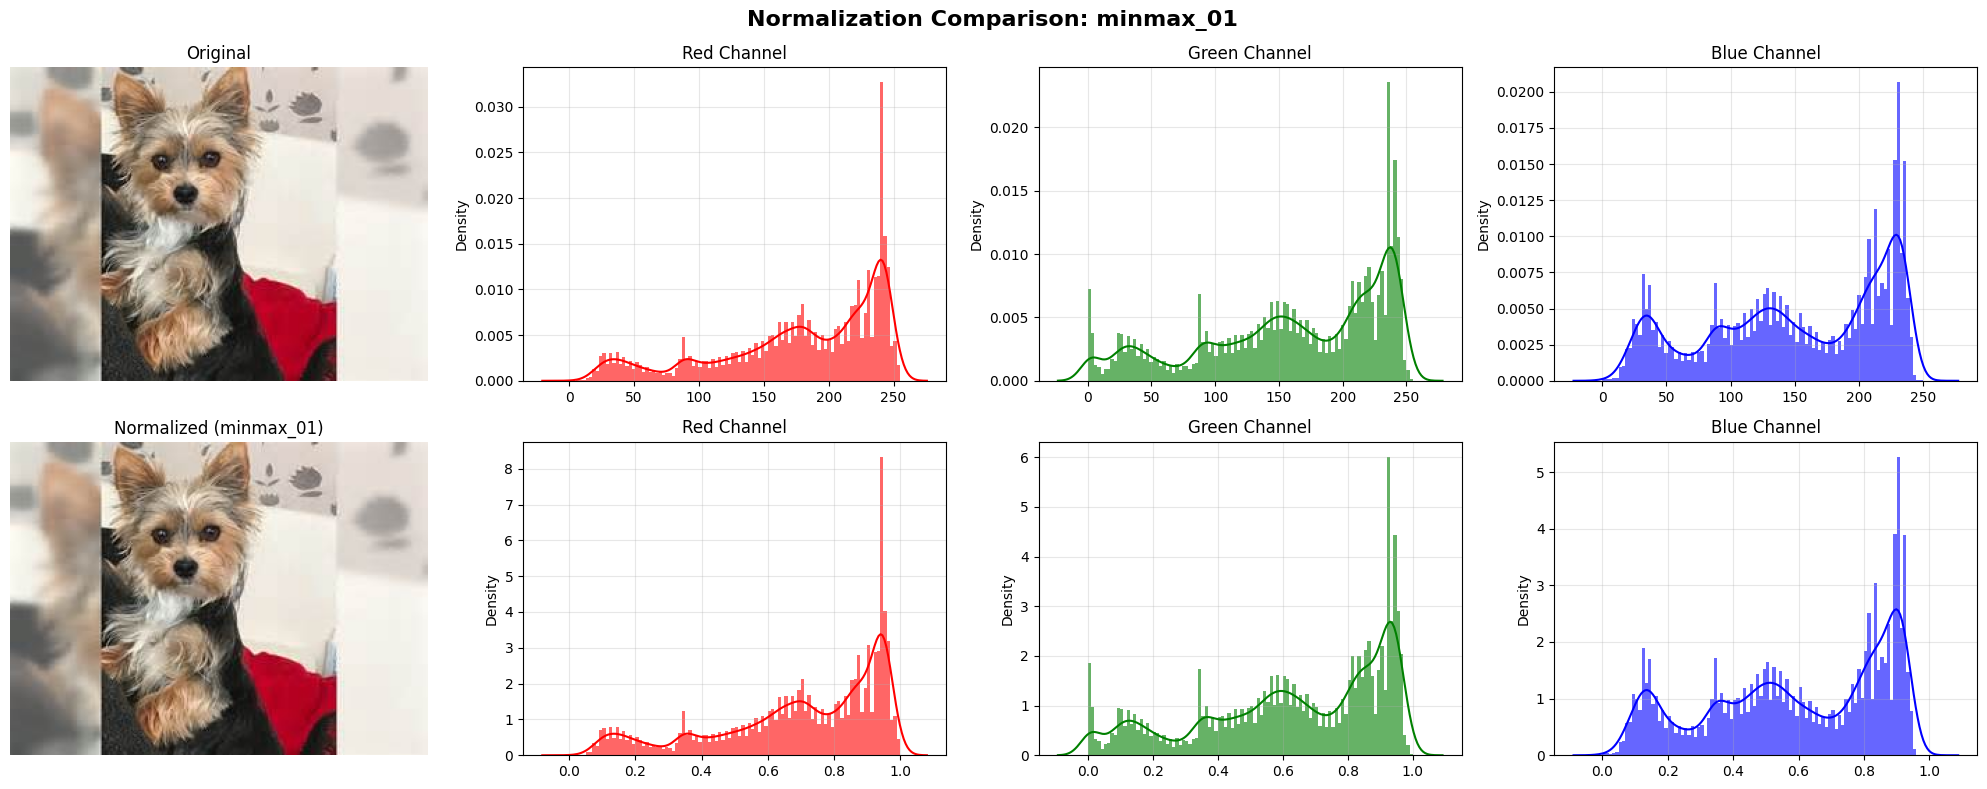

   [INFO] Kích hoạt Chế độ Chống Tràn RAM (Toán học Chunking)...
   [INFO] Đang tính toán Stats siêu nhẹ (Né OOM 10GB)...
   [INFO] Băm nhỏ dữ liệu để đưa qua Transform -> PCA...
Method: minmax_01
  - min: 0.0000
  - max: 255.0000


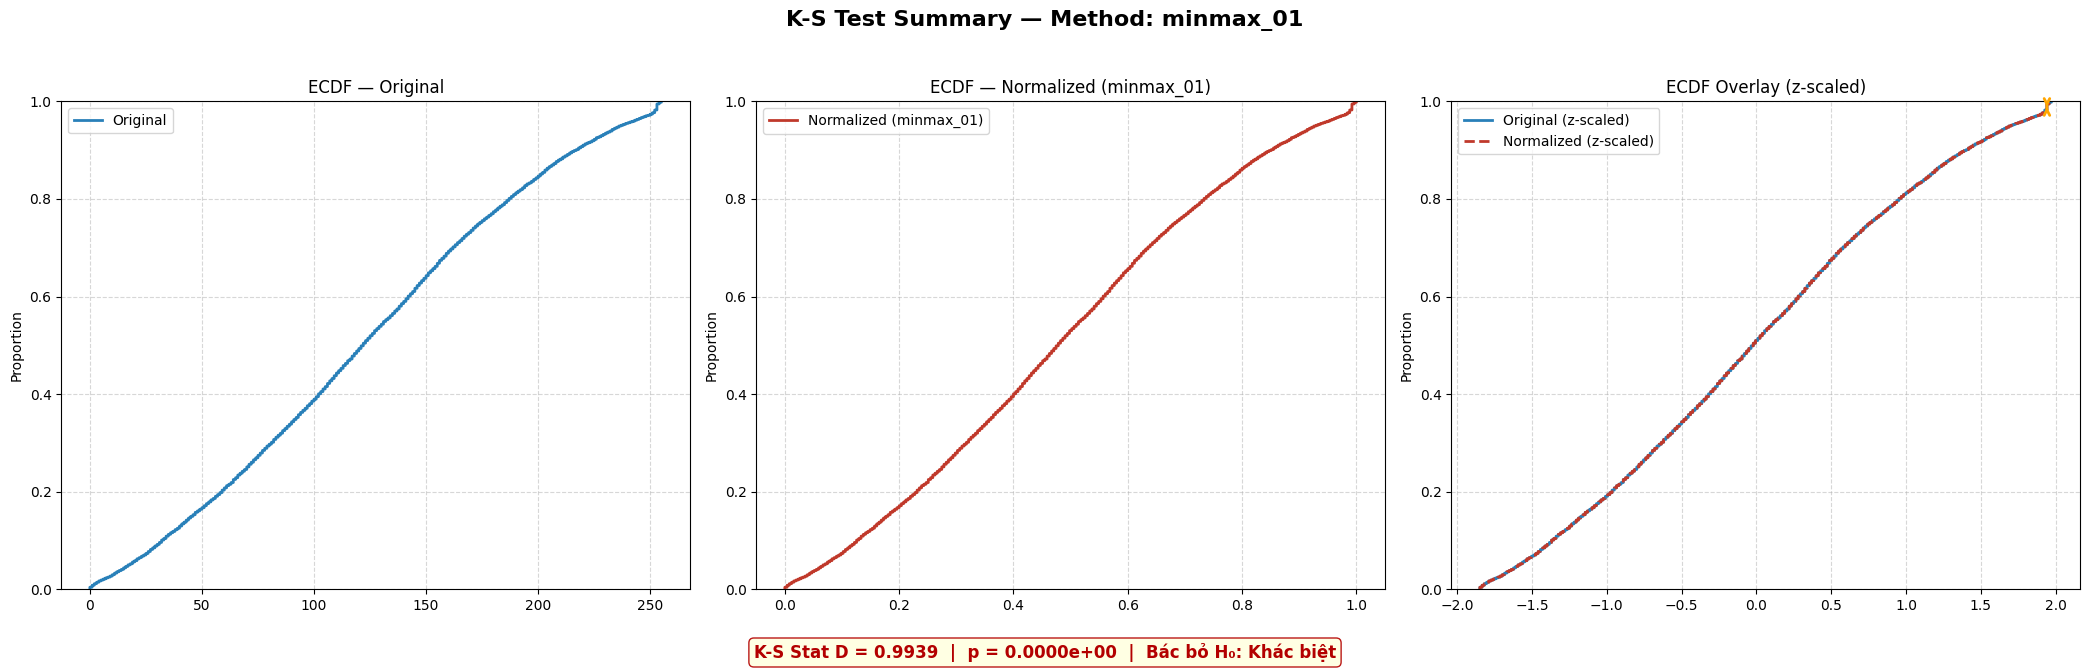


[EVALUATION] Train SGD Logistic Regression (minmax_01)...
[RESULT] minmax_01 - F1: 0.1729


PHƯƠNG PHÁP: minmax_m11


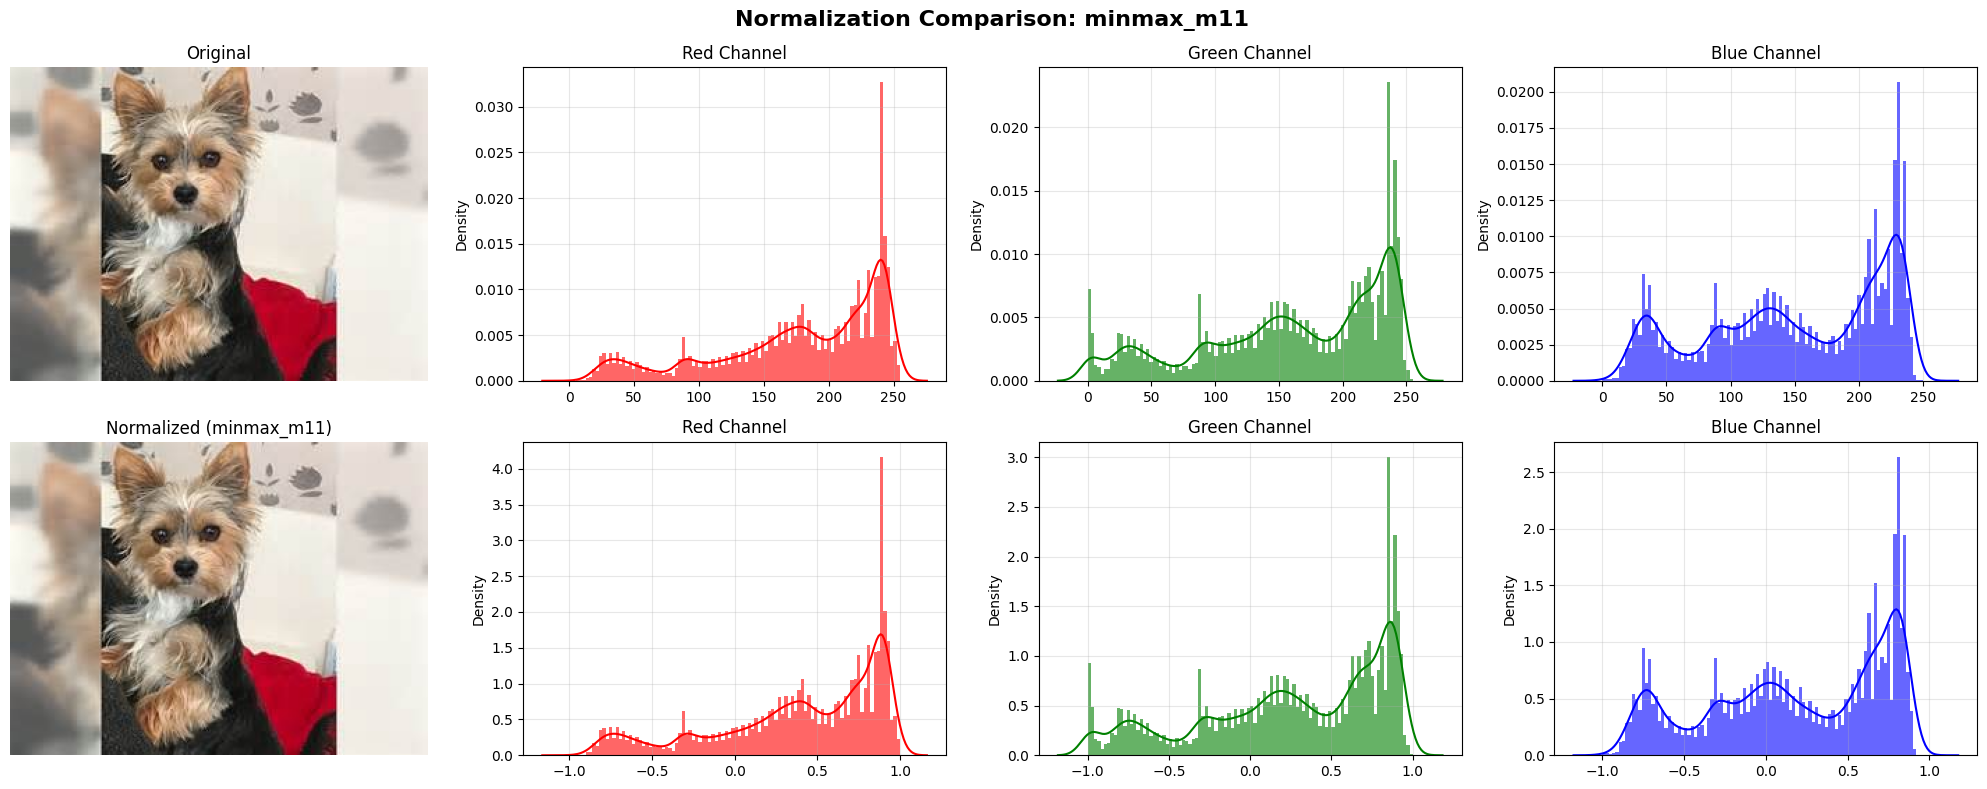

   [INFO] Kích hoạt Chế độ Chống Tràn RAM (Toán học Chunking)...
   [INFO] Đang tính toán Stats siêu nhẹ (Né OOM 10GB)...
   [INFO] Băm nhỏ dữ liệu để đưa qua Transform -> PCA...
Method: minmax_m11
  - min: 0.0000
  - max: 255.0000


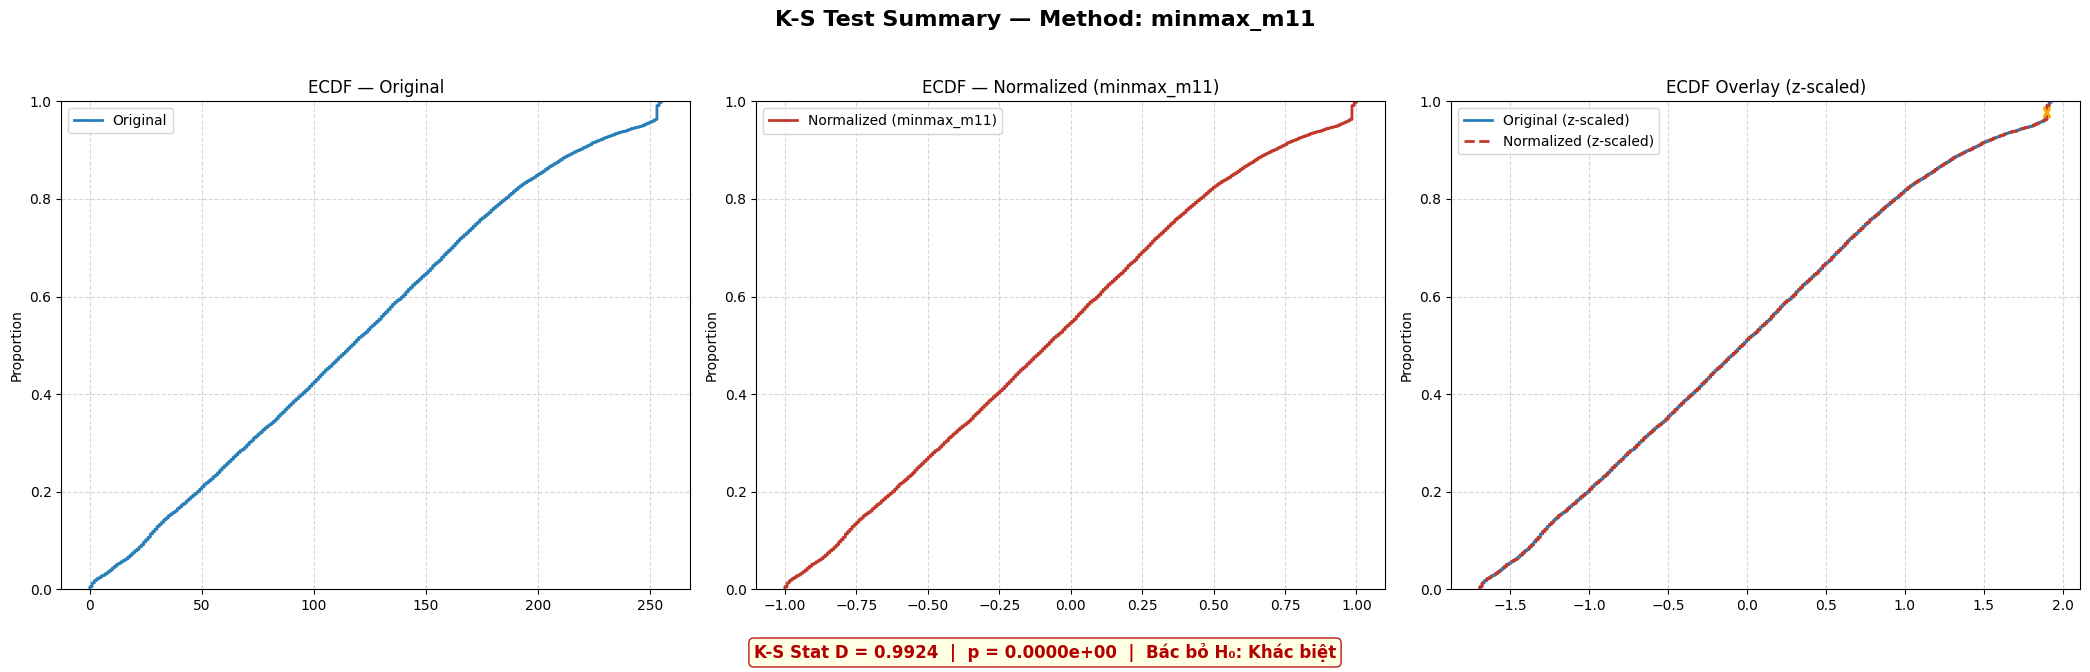


[EVALUATION] Train SGD Logistic Regression (minmax_m11)...
[RESULT] minmax_m11 - F1: 0.1741


PHƯƠNG PHÁP: zscore_global


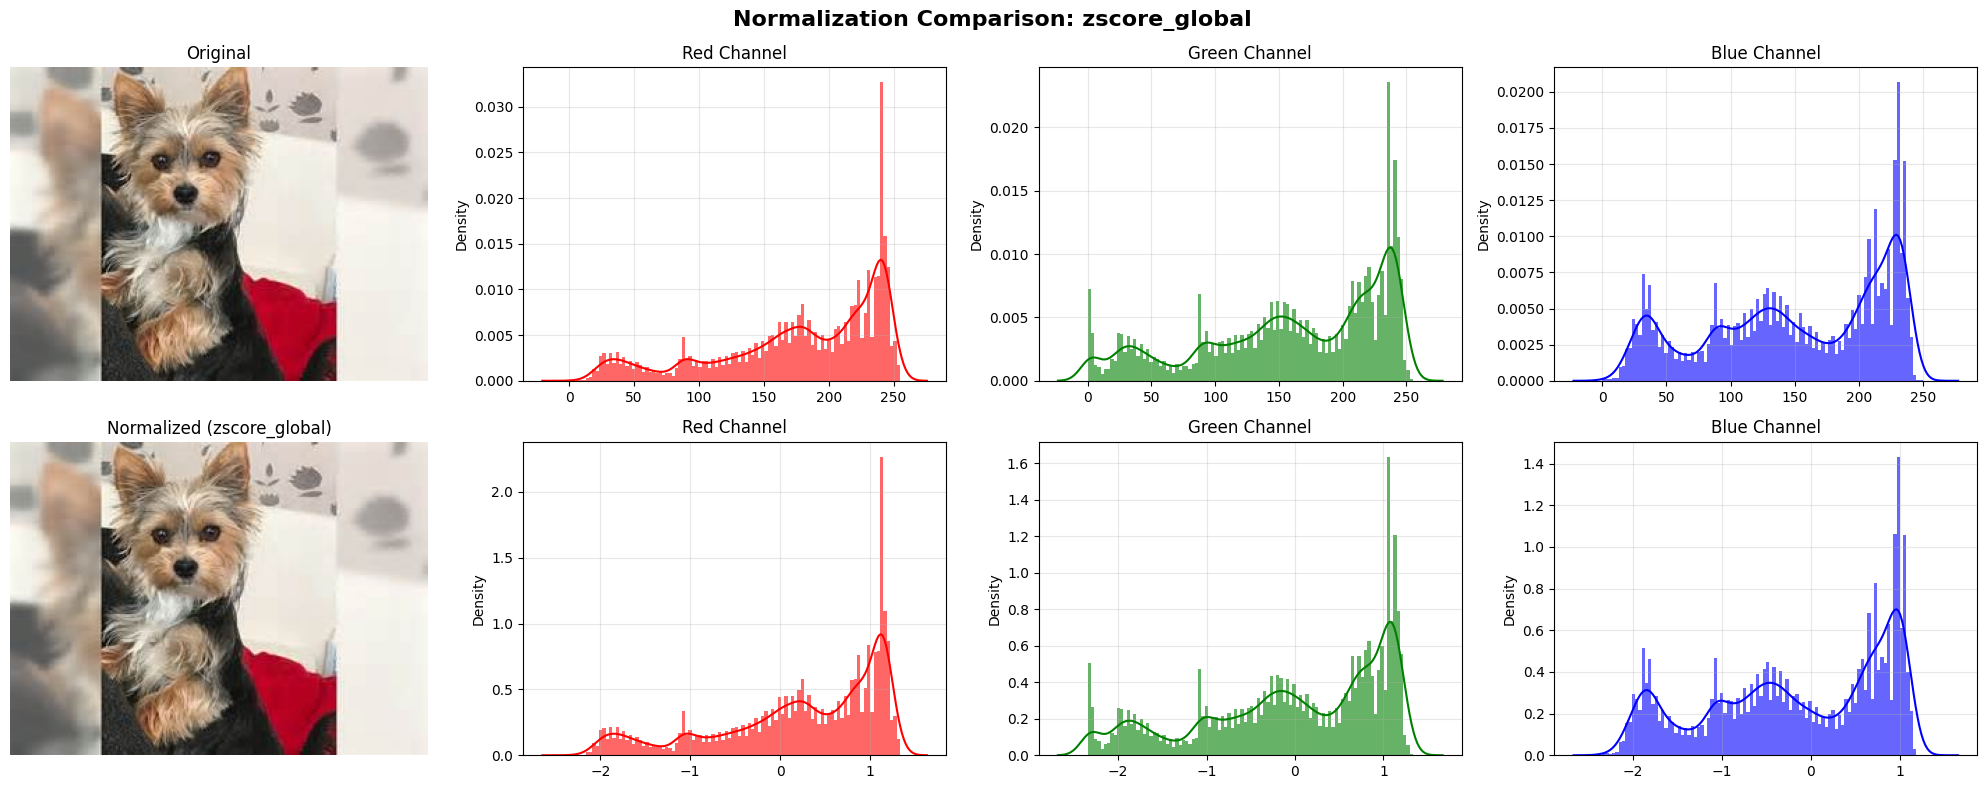

   [INFO] Kích hoạt Chế độ Chống Tràn RAM (Toán học Chunking)...
   [INFO] Đang tính toán Stats siêu nhẹ (Né OOM 10GB)...
   [INFO] Băm nhỏ dữ liệu để đưa qua Transform -> PCA...
Method: zscore_global
  - mean: 121.4851
  - std: 69.8753


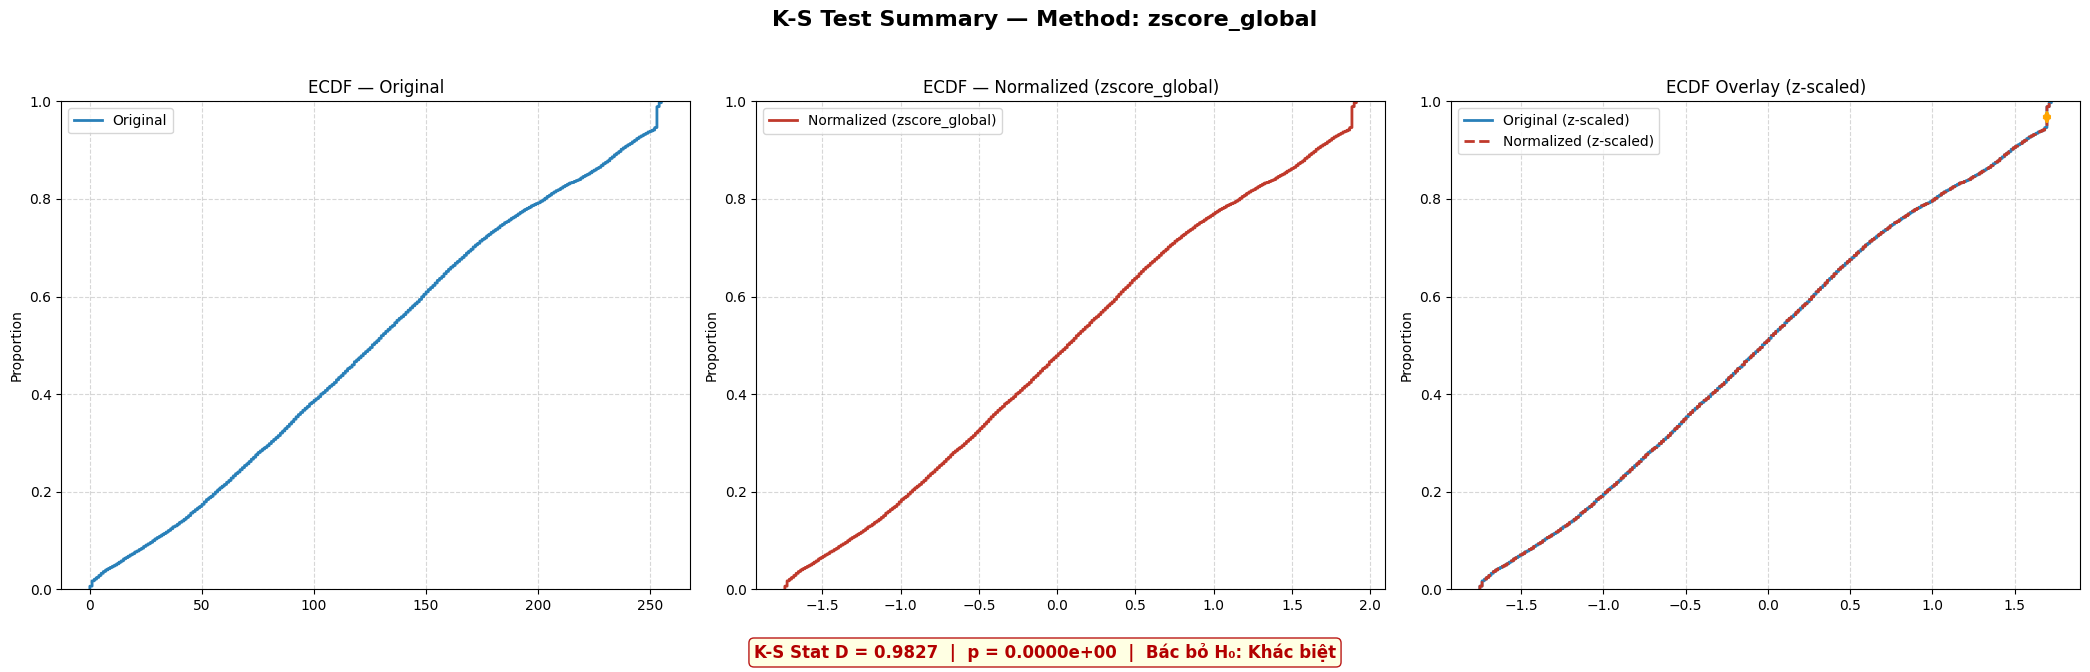


[EVALUATION] Train SGD Logistic Regression (zscore_global)...
[RESULT] zscore_global - F1: 0.1693


PHƯƠNG PHÁP: zscore_channel


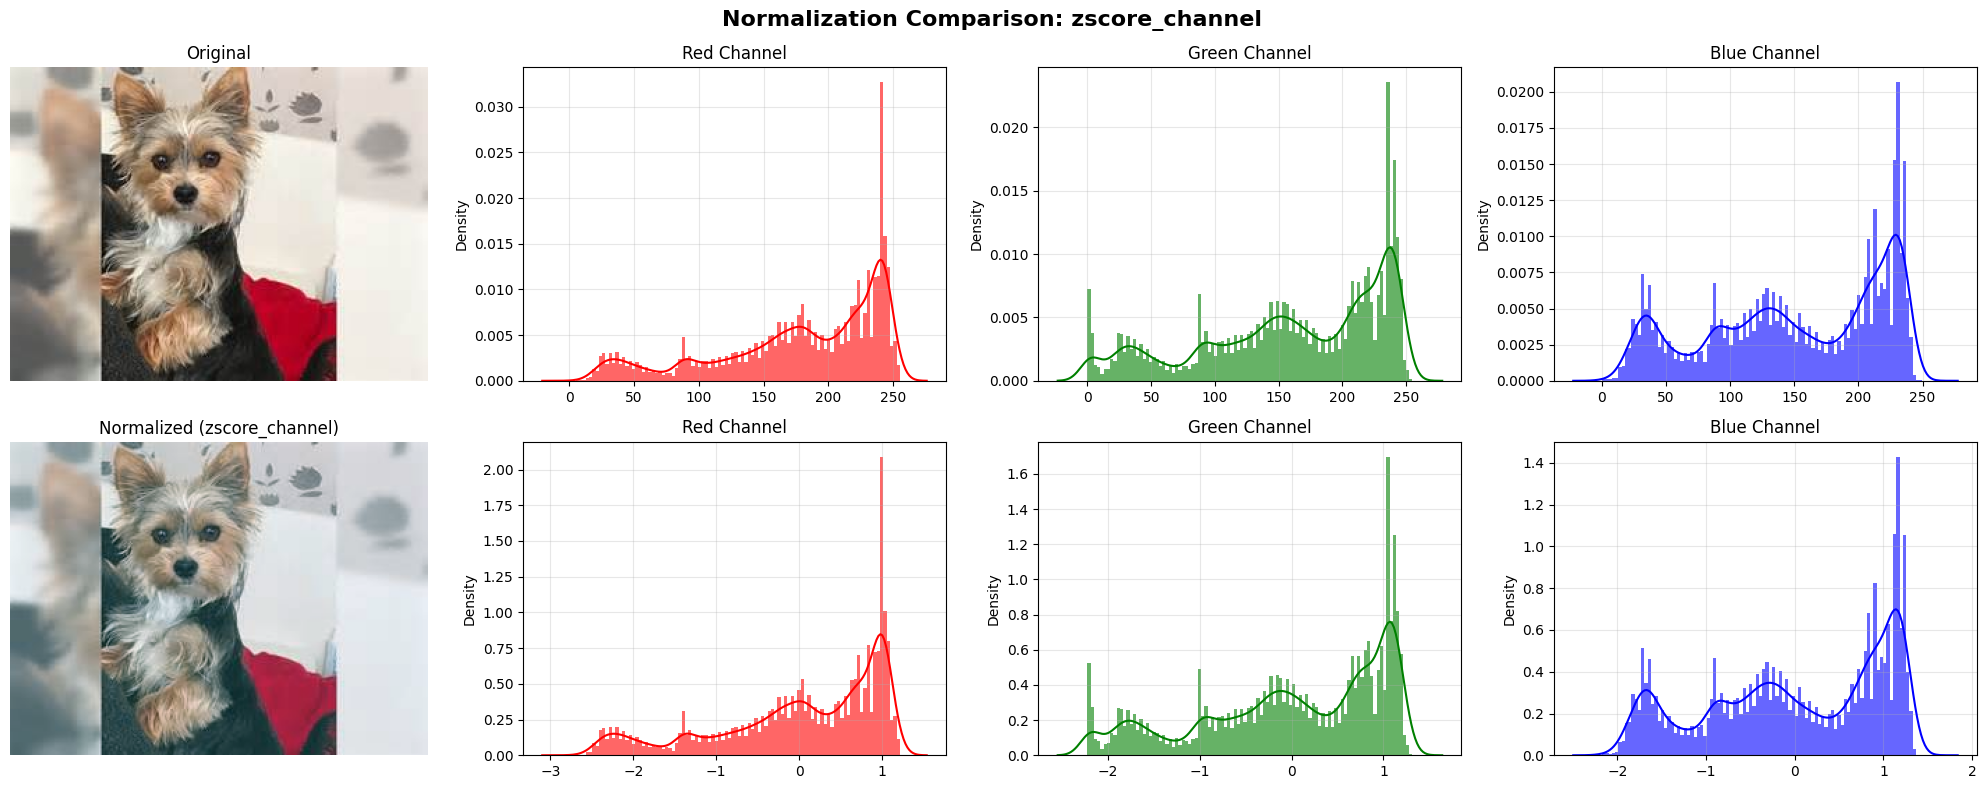

   [INFO] Kích hoạt Chế độ Chống Tràn RAM (Toán học Chunking)...
   [INFO] Đang tính toán Stats siêu nhẹ (Né OOM 10GB)...
   [INFO] Băm nhỏ dữ liệu để đưa qua Transform -> PCA...
Method: zscore_channel
  - mean: [131.90220642089844, 127.46320343017578, 105.08979797363281]
  - std: [68.21749877929688, 66.96219635009766, 71.39360046386719]


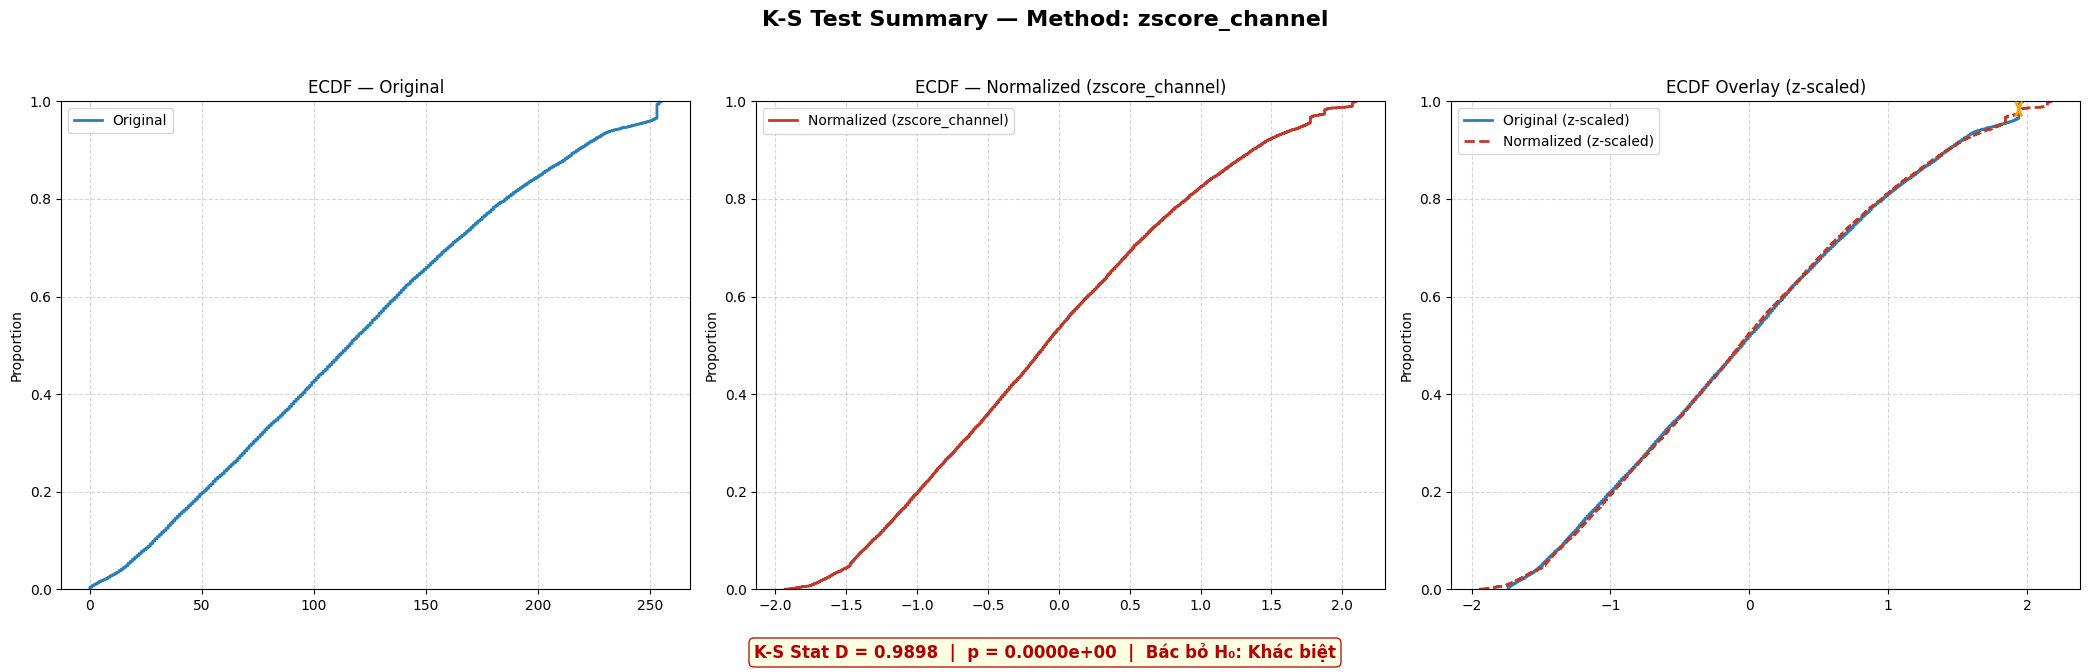


[EVALUATION] Train SGD Logistic Regression (zscore_channel)...
[RESULT] zscore_channel - F1: 0.1821


KẾT QUẢ KIỂM ĐỊNH KOLMOGOROV-SMIRNOV:


,Method,K-S Stat (D),p-value
0,minmax_01,0.9939,0.0000e+00
1,minmax_m11,0.9924,0.0000e+00
2,zscore_global,0.9827,0.0000e+00
3,zscore_channel,0.9898,0.0000e+00



BIỂU ĐỒ TỔNG HỢP SO SÁNH K-S TEST:


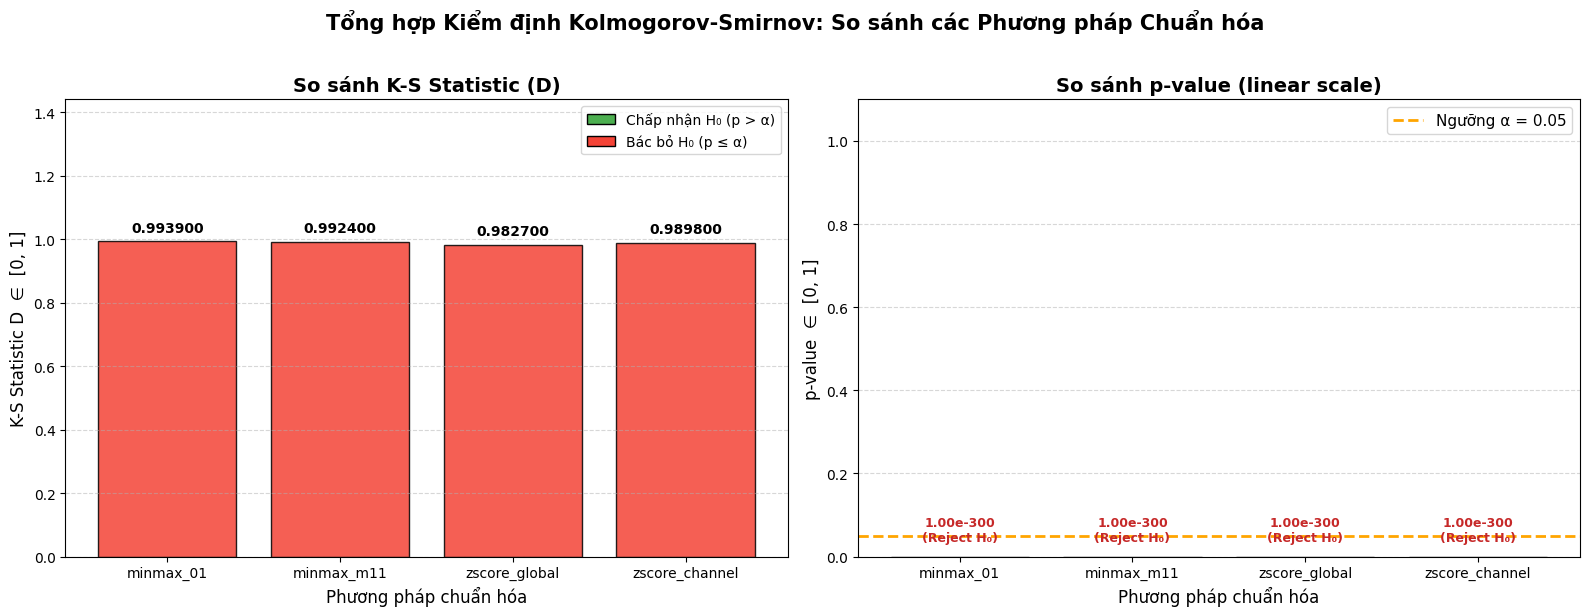


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (SGD CLASSIFIER):


,accuracy,precision,recall,f1_score,Method
0,0.183346,0.181141,0.183346,0.172856,minmax_01
1,0.186784,0.181458,0.186784,0.174147,minmax_m11
2,0.181054,0.174771,0.181054,0.169334,zscore_global
3,0.187293,0.188506,0.187293,0.182135,zscore_channel


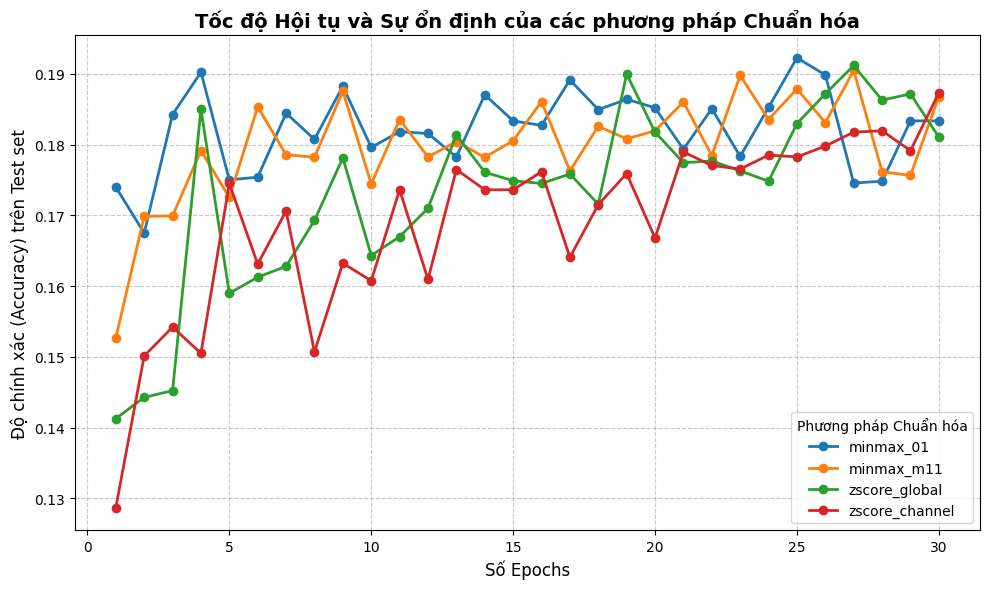

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Nạp dataset để visualize 1 batch mẫu
batch_gen = dataset.load()
first_batch, _ = next(batch_gen)
sample_img = first_batch[0].copy()

methods = ["minmax_01", "minmax_m11", "zscore_global", "zscore_channel"]

final_metrics = []
learning_curves_dict = {}
ks_results = []

for method in methods:
    print(f"\n{'='*50}\nPHƯƠNG PHÁP: {method}\n{'='*50}")
    
    norm_tool_viz = NormalizationEvaluator(method=method)
    img_viz = norm_tool_viz.fit_transform(sample_img)
    plot_normalization_comparison(sample_img, img_viz, method)
    
    norm_tool = NormalizationEvaluator(method=method)
    norm_tool.run(dataset)
    
    stat, p_value, orig_f, norm_f = norm_tool.kolmogorov_smirnov_test(sample_size=10000)
    plot_ks_test_results(orig_f, norm_f, method, stat, p_value)
    
    ks_results.append({
        "Method": method,
        "K-S Stat (D)": stat,
        "p-value": f"{p_value:.4e}"
    })
    
    metrics, epoch_curve = norm_tool.evaluation(n_repeats=3, max_epochs=30)
    if metrics:
        metrics["Method"] = method
        final_metrics.append(metrics)
        learning_curves_dict[method] = epoch_curve
    
    # Lưu ảnh ra disk 
    # norm_tool.save_images()

print("\nKẾT QUẢ KIỂM ĐỊNH KOLMOGOROV-SMIRNOV:")
df_ks = pd.DataFrame(ks_results)
display(df_ks)

print("\nBIỂU ĐỒ TỔNG HỢP SO SÁNH K-S TEST:")
plot_ks_comparison_summary(ks_results, alpha=0.05)

if final_metrics:
    print("\nKẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (SGD CLASSIFIER):")
    df_metrics = pd.DataFrame(final_metrics)
    display(df_metrics)

if learning_curves_dict:
    plot_normalization_learning_curves(learning_curves_dict)

<a id="sec-4"></a>
# 4. Kết quả và Tổng kết

<a id="sec-4-1"></a>
## 4.1. Đánh giá Kolmogorov-Smirnov

Kết quả kiểm định K-S trên cả 4 phương pháp cho thấy:
| Phương pháp | K-S Stat (D) | p-value |
|:---|:---|:---|
| minmax_01 | 0.9939 | ~0 |
| minmax_m11 | 0.9924 |~0 |
| zscore_global | 0.9827 | ~0 |
| zscore_channel | 0.9898 | ~0 |

- Về chỉ số $D$: Cả 4 phương pháp đều cho giá trị $D$ rất cao (tiệm cận 1.0), chứng tỏ phân phối pixel sau chuẩn hóa đã thay đổi hoàn toàn so với phân phối gốc.
- Về ý nghĩa thống kê: Chỉ số $p\text{-value}$ của cả 4 phương pháp đều bằng 0, thấp hơn đáng kể so với mức ý nghĩa $\alpha = 0.05$. Vì vậy, có thể bác bỏ giả thuyết $H_0$ (giả thuyết cho rằng hai phân phối tương đồng) với độ tin cậy cao.
- Kết quả này hoàn toàn phù hợp với kỳ vọng, vì mục đích của chuẩn hóa là tái cấu trúc miền giá trị pixel từ $[0, 255]$ sang các khoảng mới như $[0, 1]$, $[-1, 1]$ hoặc theo phân phối chuẩn ($z\text{-score}$). Sự khác biệt rõ rệt giữa hai phân phối cho thấy việc phép chuẩn hóa đã thực hiện đúng chức năng.

**Kết luận:** Cả 4 kỹ thuật chuẩn hóa đều tác động mạnh mẽ và làm biến đổi đáng kể phân phối dữ liệu. Việc không có phương pháp nào giữ nguyên phân phối gốc cho thấy pipeline tiền xử lý đang hoạt động ổn định và chính xác.

<a id="sec-4-2"></a>
## 4.2. Đánh giá các tiêu chí chuẩn hóa
**Tính dịch tâm về 0**

- **minmax_01:** Không có tính dịch tâm. Phân phối Histogram nằm ở phần dương của trục hoành (từ $0$ đến $1$), cho thấy không có mốc trung tâm $0$.
- **minmax_m11, zscore_global và zscore_channel:** Đều mang tính dịch tâm. Histogram có dữ liệu trải đều qua trục tung $0$. Trên biểu đồ Heatmap, giá trị $0$ được thể hiện bằng màu trắng, các pixel có giá trị âm (màu xanh) và giá trị dương (màu đỏ).

**Tính đồng nhất dải giá trị:** Nhìn chung các ảnh sau khi áp dụng các phương pháp chuẩn hóa đều cho kết quả nằm trong khoảng dự đoán.
- **minmax_01 và minmax_m11:** có các giá trị trong đoạn $[0, 1]$ và $[-1, 1]$.
- **zscore_global và zscore_channel:** Không có khoảng giá trị cố định $\min/\max$ mà tuân theo quy luật thống kê, dải giá trị phần lớn tập trung trong khoảng $[-2.5, 1.5] (xem ảnh bên dưới)$.

**Bảo toàn phân phối:** Cả 4 phương pháp đều thỏa mãn tiêu chí này. Hình dáng phân phối các đỉnh và thung lũng đặc trưng của ảnh gốc được giữ nguyên trên Histogram của cả 4 kết quả. Không có hiện tượng biến dạng, gãy nứt hay xuất hiện các khoảng trống (gaps) bất thường. Điều này khẳng định các phép biến đổi là tuyến tính, không làm mất đi các đặc trưng cấu trúc ảnh.

<a id="sec-4-3"></a>
## 4.3. Đánh giá hiệu năng mô hình (SGD Classifier)

| Phương pháp | Accuracy | Precision | Recall | F1-score |
|:---|:---|:---|:---|:---|
| minmax_01 | 0.1833 | 0.1811 | 0.1833 | 0.1729 |
| minmax_m11 | 0.1868 | 0.1815 | 0.1868 | 0.1741 |
| zscore_global | 0.1811 | 0.1748 | 0.1811 | 0.1693 |
| zscore_channel | 0.1873 | 0.1885 | 0.1873 | 0.1821 |

- zscore_channel cho kết quả tối ưu nhất với $F1\text{-score} = 0.1821$. Chỉ số Precision của phương pháp này cũng dẫn đầu ($0.1885$), cho thấy việc chuẩn hóa theo từng kênh màu giúp mô hình phân hóa các lớp đối tượng hiệu quả hơn.
- minmax_m11 đứng ở vị trí thứ hai ($F1 = 0.1741$), theo sát là minmax_01 ($F1 = 0.1729$). Sự chênh lệch giữa hai biến thể Min-Max là không đáng kể.
- zscore_global có hiệu năng thấp nhất ($F1 = 0.1693$). Nguyên nhân có thể do việc áp dụng chung thông số trung bình ($\mu$) và độ lệch chuẩn ($\sigma$) cho cả ba kênh màu đã làm mờ các đặc trưng riêng biệt của từng kênh.
- Nhìn chung, các giá trị $F1\text{-score}$ đều ở mức thấp (dưới $0.2$). Điều này phản ánh sự khó khăn trong việc phân loại khi sử dụng mô hình tuyến tính đơn giản (SGD Classifier) trên dữ liệu ảnh thô chưa qua xử lý.

<a id="sec-4-4"></a>
## 4.4. Tổng kết

- Về mặt thống kê: Cả 4 phương pháp đều thực hiện biến đổi phân phối thành công và triệt để (chỉ số $D \approx 1.0$, $p\text{-value} = 0$).
- Về hiệu năng mô hình: zscore_channel mang lại hiệu quả phân loại tối ưu nhất, kế đến là minmax_m11, minmax_01 và cuối cùng là zscore_global.
- Ưu tiên sử dụng kỹ thuật zscore_channel. Phương pháp này không chỉ đảm bảo tính dịch tâm dữ liệu về giá trị 0 (zero-centering) mà còn tối ưu hóa đặc thù cho từng kênh màu, giúp bảo toàn và khai thác tốt hơn các đặc trưng màu sắc của ảnh.
